PREDICTING STARTUP SURVIVAL: A MACHINE LEARNING PERSPECTIVE
 
> In questa tesi vengono combinate tecniche di Data Mining e Machine Learning
con l’obiettivo di identificare i principali fattori di rischio per le startup (con un
particolare focus su Competitors, Team e Funding), in modo da prevederne l’eventuale fallimento.

> I dati presi in esame provengono dalla piattaforma PitchBook, e
sono stati elaborati in linea con la letteratura economica recente.

> A partire dalle metriche calcolate, sono stati addestrati diversi modelli (Alberi
Decisionali, Random Forest, Reti Neurali Artificiali), i quali sono stati successivamente valutati in base alla capacità di classificare correttamente le startup fallite.
Questi esperimenti hanno permesso, inoltre, di cogliere i principali indicatori di "sopravvivenza" delle startup, mediante il valore dell’importanza che ogni modello
assegna a una determinata feature. Un ulteriore studio è stato svolto tramite l’impiego del Random Survival Forest, una versione alternativa del Random Forest
ideata per l’analisi della sopravvivenza.

In [19]:
%load_ext autoreload
%autoreload 2

import os
from dotenv import load_dotenv 
import yaml
import json

import pandas as pd
import polars as pl
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from src.preprocessing import processUniversityList, getFlagTop50Institute,lump_categories
from src.utils import plot_correlation_heatmap,get_high_correlations,to_tensors,get_probs


from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from src.models.MLP import MLP


from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score, roc_auc_score)
import wandb
import shap
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt # Necessario per salvare i grafici
from matplotlib.patches import Patch
import seaborn as sns


from scipy.stats import wilcoxon
import scipy.integrate
if not hasattr(np, 'trapz'):
    np.trapz = scipy.integrate.trapezoid

load_dotenv()

with open('config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Temporizzazione Competitors

In [ ]:
# ============================================================
# 1. LETTURA DEI TRE FILE
# ============================================================
panel = pl.read_csv(config['paths']['raw_dataset'], null_values=["NA"])
companies = pl.read_csv("data/raw/Company.csv", null_values=["NA"])
competitors_raw = pl.read_csv("data/raw/CompanySimilarRelation.csv", null_values=["NA"])

# ============================================================
# 2. CALCOLO YearFounded e MaxYear PER OGNI AZIENDA
# ============================================================
date_cols = [
    "CompanyFinancingStatusDate",
    "BusinessStatusDate",
    "OwnershipStatusDate",
    "FirstFinancingDate",
    "LastKnownValuationDate",
]

for col in date_cols:
    if col in companies.columns:
        companies = companies.with_columns(
            pl.col(col)
            .str.to_date("%m/%d/%Y", strict=False)
            .fill_null(pl.col(col).str.to_date("%m/%d/%y", strict=False))
            .alias(col)
        )

if "FiscalPeriod" in companies.columns:
    companies = (
        companies
        .with_columns(
            pl.col("FiscalPeriod").str.extract(r"(\d{4})$").cast(pl.Int32, strict=False).alias("_fy"),
            pl.col("FiscalPeriod").str.extract(r"(\d)Q").cast(pl.Int32, strict=False).alias("_fq"),
        )
        .with_columns(
            pl.when(pl.col("_fq") == 1).then(3)
            .when(pl.col("_fq") == 2).then(6)
            .when(pl.col("_fq") == 3).then(9)
            .when(pl.col("_fq") == 4).then(12)
            .otherwise(None)
            .alias("_fm")
        )
        .with_columns(pl.date(pl.col("_fy"), pl.col("_fm"), 28).alias("FiscalDate"))
        .drop("_fy", "_fq", "_fm")
    )
else:
    companies = companies.with_columns(pl.lit(None).cast(pl.Date).alias("FiscalDate"))

all_date_cols = [c for c in date_cols + ["FiscalDate"] if c in companies.columns]
year_aliases = [f"_y_{c}" for c in all_date_cols]

companies = companies.with_columns([
    pl.col(c).dt.year().cast(pl.Int32, strict=False).alias(f"_y_{c}")
    for c in all_date_cols
])

companies = companies.with_columns(
    pl.max_horizontal([pl.col(y) for y in year_aliases]).alias("MaxYear"),
    pl.col("YearFounded").cast(pl.Int32, strict=False),
)

# Lookup: CompanyID -> YearFounded, MaxYear, HQCountry
company_life = (
    companies
    .select("CompanyID", "YearFounded", "MaxYear", "HQCountry")
    .filter(pl.col("YearFounded").is_not_null() & pl.col("MaxYear").is_not_null())
)

# ============================================================
# 3. FILTRA E ARRICCHISCI
# ============================================================
# Qui usiamo direttamente competitors_raw: la relazione è letta
# come "CompanyID dichiara SimilarCompanyID come sua simile/competitor".
# Non aggiungiamo la direzione inversa.

valid_panel_ids = panel.select("CompanyID").unique().to_series()
valid_company_ids = company_life.select("CompanyID").unique().to_series()

# --- 3a. COMPETITOR (IsCompetitor == "Yes") ---
comp = (
    competitors_raw
    .filter(
        (pl.col("IsCompetitor") == "Yes") &
        pl.col("CompanyID").is_in(valid_panel_ids) &
        pl.col("SimilarCompanyID").is_in(valid_company_ids)
    )
    .select("CompanyID", "SimilarCompanyID", "SimilarityScore")
    # Finestra di vita del competitor
    .join(
        company_life.select(
            pl.col("CompanyID").alias("SimilarCompanyID"),
            pl.col("YearFounded").alias("YF_comp"),
            pl.col("MaxYear").alias("MY_comp"),
            pl.col("HQCountry").alias("HQCountry_comp"),
        ),
        on="SimilarCompanyID",
        how="inner",
    )
    # Nazione dell'azienda del panel
    .join(
        company_life.select("CompanyID", pl.col("HQCountry").alias("HQCountry_panel")),
        on="CompanyID",
        how="left",
    )
    .with_columns(
        # null se una delle due HQCountry manca: escluso dal conteggio, non contato come False
        (pl.col("HQCountry_panel") == pl.col("HQCountry_comp")).alias("SameCountry")
    )
    .drop("HQCountry_panel", "HQCountry_comp")
)

print(f"Coppie competitor filtrate: {comp.height}")

# --- 3b. TUTTE LE AZIENDE SIMILI (per media SimilarityScore) ---
similar_all = (
    competitors_raw
    .filter(
        pl.col("CompanyID").is_in(valid_panel_ids) &
        pl.col("SimilarCompanyID").is_in(valid_company_ids)
    )
    .select("CompanyID", "SimilarCompanyID", "SimilarityScore")
    .join(
        company_life.select(
            pl.col("CompanyID").alias("SimilarCompanyID"),
            pl.col("YearFounded").alias("YF_sim"),
            pl.col("MaxYear").alias("MY_sim"),
        ),
        on="SimilarCompanyID",
        how="inner",
    )
)

print(f"Coppie simili totali: {similar_all.height}")

# ============================================================
# 4. JOIN CON INEQUALITY
# ============================================================
panel_years = panel.select("CompanyID", "Year_Delta").unique()

# 4a. Competitor attivi
matched_comp = panel_years.join_where(
    comp,
    pl.col("CompanyID") == pl.col("CompanyID_right"),
    pl.col("Year_Delta") >= pl.col("YF_comp"),
    pl.col("Year_Delta") <= pl.col("MY_comp"),
)

# 4b. Tutte le aziende simili attive
matched_sim = panel_years.join_where(
    similar_all,
    pl.col("CompanyID") == pl.col("CompanyID_right"),
    pl.col("Year_Delta") >= pl.col("YF_sim"),
    pl.col("Year_Delta") <= pl.col("MY_sim"),
)

# ============================================================
# 5. AGGREGA PER AZIENDA-ANNO
# ============================================================
competitor_stats = (
    matched_comp
    .group_by("CompanyID", "Year_Delta")
    .agg(
        pl.col("SimilarCompanyID").n_unique().alias("N_ActiveCompetitors"),
        pl.col("SameCountry").drop_nulls().sum().cast(pl.Int64).alias("N_ActiveCompetitors_SameCountry"),
    )
)

similarity_stats = (
    matched_sim
    .group_by("CompanyID", "Year_Delta")
    .agg(
        pl.col("SimilarityScore").mean().alias("Mean_SimilarityScore"),
    )
)

# ============================================================
# 6. UNISCI AL PANEL
# ============================================================
panel = (
    panel
    .join(competitor_stats, on=["CompanyID", "Year_Delta"], how="left")
    .join(similarity_stats, on=["CompanyID", "Year_Delta"], how="left")
    .with_columns(
        pl.col("N_ActiveCompetitors").fill_null(0),
        pl.col("N_ActiveCompetitors_SameCountry").fill_null(0),
        pl.col("Mean_SimilarityScore").fill_null(0.0),
    )
)

# ============================================================
# 7. COMPETITOR STATS SENZA FINESTRA TEMPORALE (per esperimento nowindow)
# Conta tutti i competitor dichiarati indipendentemente dalla loro finestra di vita.
# ============================================================
nowindow_competitor_stats = (
    comp
    .group_by("CompanyID")
    .agg(
        pl.col("SimilarCompanyID").n_unique().alias("N_AllCompetitors"),
        pl.col("SameCountry").drop_nulls().sum().cast(pl.Int64).alias("N_AllCompetitors_SameCountry"),
    )
)

nowindow_similarity_stats = (
    similar_all
    .group_by("CompanyID")
    .agg(
        pl.col("SimilarityScore").mean().alias("Mean_AllSimilarityScore"),
    )
)

In [ ]:
temporal_features=panel.select(
        "CompanyID", "Year_Delta",
        "N_ActiveCompetitors","N_ActiveCompetitors_SameCountry", 
        "Mean_SimilarityScore"
    )

Lettura della versione iniziale del dataset "master" 

In [ ]:
df = pl.read_csv(config['paths']['raw_dataset'],null_values=["NA"])

df = (
    df
    .drop("N_Competitors", "Same_Country", "SimilarityScoreMean")
    .join(temporal_features, on=["CompanyID", "Year_Delta"], how="left")
    .rename({
        "N_ActiveCompetitors": "N_Competitors",
        "N_ActiveCompetitors_SameCountry": "Same_Country",
        "Mean_SimilarityScore": "SimilarityScoreMean",
    })
)
print(f'Colonne: {len(df.columns)}') 
print(f'Righe: {len(df)}')

# Sostituisco "Stay" con il valore attuale di "GrowthStageGroup"
df = df.with_columns(
    pl.when(pl.col("GrowthNextStageGroup") == "Stay")
    .then(pl.col("GrowthStageGroup"))
    .otherwise(pl.col("GrowthNextStageGroup"))
    .alias("GrowthNextStageGroup")
)

Pre-processing
Il dataset di partenza è un panel in cui ogni azienda presenta un record per ogni anno di vita disponibile.
Nell' ottica di sperimentare con modelli di classificazione, si è scelto di focalizzarsi sui dati delle aziende che si trovano in fase di Early per provare a prevederne la condizione al qT-esimo anno successivo. Per fare ciò, il dataset viene raggruppato per azienda, mantenendo i valori delle features all'entrata nella fase Early; la variabile target viene invece mantenuta al T-esimo anno successivo o all'ultimo dato disponibile.   

Per evitare troppa diversità tra le aziende sono stati applicati alcuni filtri:
 - Il valore di Age all'entrata della fase Early deve essere <=2 (è così per la maggior parte delle aziende a parte alcuni outliers che vengono così eliminati)
 - L'anno di fondazione deve essere compreso tra il 2010 e il 2024-T (i dati si fermano al 2024)


In [ ]:
T=int(os.getenv("time_window"))

lastYear=2024-T

nowindow=False

if(nowindow): #esperimento senza finestra temporale

    # Per ogni CompanyID del dataset che modella la finestratemporale, seleziona la riga con Age massimo
    # dove GrowthStageGroup, GrowthNextStageGroup e Total_People non sono nulli.
    # Se la riga con Age massimo ha valori nulli, prende la precedente valida.
    
    dataset_window = pl.read_csv(config['paths']['dataset_window'],null_values=["NA"])

    ids_prev=dataset_window["CompanyID"].to_list()
    print(len(ids_prev))

    df_no_tw = (
        df
        .sort(["CompanyID", "Age"])
        .filter(
            pl.col("CompanyID").is_in(ids_prev) &
            pl.col("GrowthStageGroup").is_not_null() &
            pl.col("GrowthNextStageGroup").is_not_null() &
            pl.col("Total_People").is_not_null()
        )
        .group_by("CompanyID")
        .agg([
            pl.all().exclude(["TotalRaised_Est", "WorkExp_Idx_Mean", "Highest_Degree_Mean",'Avg_Earliest_Year'])
            .sort_by("Age").last(),
            pl.col("TotalRaised_Est").sum(),
            pl.col("WorkExp_Idx_Mean").mean(),
            pl.col("Highest_Degree_Mean").mean(),
            pl.col("Avg_Earliest_Year").mean(),
        ])
    )

    df_target_final = df_no_tw.rename({"GrowthNextStageGroup": "Target"})

    # Sostituisci i competitor temporalizzati con quelli statici (tutti i competitor, senza filtro annuale)
    df_target_final = (
        df_target_final
        .drop("N_Competitors", "Same_Country", "SimilarityScoreMean")
        .join(nowindow_competitor_stats, on="CompanyID", how="left")
        .join(nowindow_similarity_stats, on="CompanyID", how="left")
        .rename({
            "N_AllCompetitors": "N_Competitors",
            "N_AllCompetitors_SameCountry": "Same_Country",
            "Mean_AllSimilarityScore": "SimilarityScoreMean",
        })
        .with_columns(
            pl.col("N_Competitors").fill_null(0),
            pl.col("Same_Country").fill_null(0),
            pl.col("SimilarityScoreMean").fill_null(0.0),
        )
    )

else:

    df_preseed = df.filter(
        pl.col("GrowthStageGroup")
        .eq("Early")
        .any()
        .over("CompanyID")
    )
    df_preseed=df_preseed.drop_nulls(subset=['GrowthStageGroup'])


    df_preseed = df_preseed.select(["CompanyID", "Age"])

    # aggregazioni per azienda
    df_combined = (
        df_preseed
        .group_by("CompanyID")
        .agg([
            pl.col("Age").min().alias("StartingAge"),
            pl.col("Age").max().alias("LastAge"),
        ])
        .with_columns(
            pl.min_horizontal(
                pl.col("StartingAge") + T,
                pl.col("LastAge")
            ).alias("TargetAge")
        )
        .filter(pl.col("StartingAge") <= 2) # filtro aggiunto per evitare valori troppo diversi (in ogni caso la maggior parte delle aziende aveva un Age compreso tra 0 e 2 al momento dell'entrata in preseed)
    )

    df = df.join(df_combined, on="CompanyID")


    df_target = df.filter(
        pl.col("Age") == pl.col("TargetAge")
    ).select(["CompanyID", "StartingAge" ,"TargetAge" ,'GrowthStageGroup','TimeNextStageGroup','GrowthNextStageGroup'])


    df_target = df_target.with_columns(
        pl.when(pl.col("TargetAge") + pl.col("TimeNextStageGroup")<=pl.col("StartingAge") + T) 
        .then(pl.col("GrowthNextStageGroup"))
        .otherwise(pl.col("GrowthStageGroup"))
        .alias("Target")
    )

    df_target_panel=df.join(df_target.select(["CompanyID", "Target"]),on='CompanyID')


    df_target_final = df_target_panel.filter(
        (pl.col("Age") == pl.col("StartingAge")) &
        (pl.col("YearFounded")+pl.col("Age") <= lastYear) &
        (pl.col("YearFounded")+pl.col("Age") >= 2010)
    )


print(f'Colonne: {len(df_target_final.columns)}') 
print(f'Righe: {len(df_target_final)}')

Feature selection

In [ ]:
df_target_final=df_target_final.select(['CompanyID', 'Target' ,'YearFounded','Age', 'N_Deal', 'TotalRaised_Est', 
                                        'Percent_Females', 'Is_Eco', 'Is_Eng', 'Is_NS', 
                                        'Is_Hum', 'Is_SS', 'Is_Med', 'Is_Law', 'Is_IT', 
                                         'Institute', 'WorkExp_Idx_Mean', 'Total_Founders', 'Is_Debt', 
                                         'Is_SpinOff', 'Is_CrowdFunding',  
                                        'MeanMedianRoundAmount_cum', 'Is_Accelerator', 'has_Corporate', 
                                        'has_VentureCapital', 'has_PublicInvestor', 'has_Angel_Lead', 'has_Corporate_Lead',
                                        'has_VentureCapital_Lead', 'has_Accelerator_Lead', 'has_PrivateEquity_Lead', 'has_PublicInvestor_Lead', 
                                          'HQCountry', 'PrimaryIndustrySector',
                                        'SimilarityScoreMean', 'N_Competitors', 'Same_Country','Highest_Degree_CEO','Gender_CEO','MeanTotalInvestments_cum',
                                        'WorkExperienceIndex_CEO', 'Is_Angel',  'Total_People', 'Is_Grant','has_PrivateEquity','TotalInvestors', 'Highest_Degree_Mean','Avg_Earliest_Year'
                                        ])

Viene creata la feature booleana HasTop50Institute che ha valore positivo se almeno una delle Università citate nella colonna 'Institutes' è presente nella classifica delle 50 migliori università al mondo. La classifica è stata stilata da QS World University Rankings ed è contenuta nel file QS_World_Rankings.csv.

Per fare ciò è stato svolto un confronto di stringhe tramite Jaccard Similarity.

In fase di preprocessing e di match sono state utilizzate diverse tecniche di NLP:

> Text Normalization: 
    Prima del confronto, il codice "pulisce" il testo per ridurre la variabilità semantica. Tutto il testo viene convertito in minuscolo. Vengono rimossi caratteri speciali come virgole, trattini e spazi multipli tramite Espressioni Regolari. Il codice rimuove parole comuni che non aiutano a distinguere un'università dall'altra, come "university", "of", "the". In NLP, queste sono considerate "stop words" specifiche del dominio accademico.

> Nella funzione calculate_similarity_by_words, il codice trasforma le stringhe in insiemi di parole: La stringa viene spezzata in singole unità (parole) usando lo spazio come delimitatore (Tokenizzazione). Trasformando la lista in un set(), il codice ignora l'ordine delle parole e le ripetizioni, concentrandosi solo sulla presenza dei termini (Bag of Words).

> Viene implementata una logica di Named Entity Disambiguation basata sugli acronimi: Tramite la Regex r"\((.*?)\)" viene estratto il testo tra parentesi (es. "MIT" da "Massachusetts Institute of Technology (MIT)"). Il confronto avviene su due binari: se l'acronimo combacia, l'istituto è confermato immediatamente, riducendo i falsi negativi dovuti a nomi troppo lunghi o complessi.

> Logica di Matching Ibrida: Il confronto finale non è una semplice uguaglianza, ma un sistema a cascata: Exact Match su Acronimo: Se l'acronimo estratto è presente nella lista Top 50. Exact Match su Stringa Pulita: Se la stringa normalizzata è identica. Substring Matching: Verifica se un acronimo è contenuto all'interno del nome (es: "MIT" in "MIT Boston"). Fuzzy Matching (Soglia): Se la similarità di Jaccard supera il threshold=0.5.

In [ ]:
# Caricamento e pulizia università
top_50 = processUniversityList(config['paths']['raw_university_ranking'])

df_target_final=df_target_final.with_columns(pl.col("Institute").map_elements( lambda x: getFlagTop50Institute(x, top_50),return_dtype=pl.Boolean, 
        skip_nulls=False).alias("HasTop50Institute"))

df_target_final=df_target_final.drop("Institute")

counts = df_target_final["HasTop50Institute"].value_counts()

Rimozione nazioni non abbastanza frequenti e frequency encoding della colonna 'HQCountry'

Frequency encoding colonna 'PrimaryIndustryGroup'

In [ ]:
df_target_final = lump_categories(df_target_final, "HQCountry", min_count=1000)


#frequency encoding HQCountry
freq_df = df_target_final.group_by("HQCountry").agg(
    pl.len().alias("HQCountryFreq")
)

df_target_final = df_target_final.join(freq_df, on="HQCountry").drop("HQCountry")


#frequency encoding PrimaryIndustrySector

freq_df = df_target_final.group_by("PrimaryIndustrySector").agg(
    pl.len().alias("PrimaryIndustrySectorFreq")
)

df_target_final = df_target_final.join(freq_df, on="PrimaryIndustrySector").drop("PrimaryIndustrySector")


# feature indicatore per il genere del CEO
df_target_final = df_target_final.to_dummies("Gender_CEO").drop("Gender_CEO_Male").drop("Gender_CEO_null")

Gestione Missing Values

Scarto le righe che hanno missing valueas per Total_People, in quanto presentano lo stesso problema per la maggior parte delle features del team.
Conversione delle variabili booleane in numeri interi, revisione tipi variabili numeriche.

In [ ]:
df_target_final = df_target_final.drop_nulls(subset=['Total_People'])


df_target_final = df_target_final.with_columns(
    pl.col(pl.Boolean).cast(pl.Int8)
)

# #Per queste variabili si è deciso di imputare i missing values a 0
variabili_toInt = [ 'N_Competitors','Same_Country'] 

df_target_final = df_target_final.with_columns(
    [pl.col(name).cast(pl.Int64).fill_null(0) for name in variabili_toInt]

)

df_target_final = df_target_final.with_columns(
    pl.col('SimilarityScoreMean').fill_null(pl.col('SimilarityScoreMean').mean()) 

)

#Conversione mantenendo i missing values 
df_target_final = df_target_final.with_columns(
    pl.col(["YearFounded","Age",'Total_Founders','Total_People','Is_Eco','Is_Eng','Is_NS','Is_Hum','Is_SS','Is_Med','Is_Law','Is_IT']).cast(pl.Int64)
)

Missing values per feature

In [ ]:
# 1. Definiamo la soglia (40%)
threshold = 0.4

# 2. Identifichiamo le colonne da tenere
# Calcoliamo la frazione di null per ogni colonna e filtriamo i nomi
cols_to_keep = [
    col for col in df_target_final.columns 
    if df_target_final[col].null_count() / len(df_target_final) < threshold
]

if(not nowindow):
    # 3. Sovrascriviamo il dataframe (o creiamone uno nuovo)
    df_target_final = df_target_final.select(cols_to_keep)

In [ ]:
result = (
    df_target_final.select([
        (pl.col(col).null_count() / pl.len() * 100).alias(col)
        for col in df_target_final.columns
    ])
    .unpivot(variable_name="colonna", value_name="percentuale_missing")
    .filter(pl.col("percentuale_missing") > 0)
    .sort("percentuale_missing", descending=True)
)

print(result)

Missing values per i record

In [ ]:
# 1. Conta i null in modo orizzontale (molto più veloce e sicuro)
df_with_row_counts = df_target_final.with_columns(
    null_count_row = pl.sum_horizontal(pl.all().is_null())
)

# 2. Raggruppa per vedere la distribuzione
distribuzione_missing = (
    df_with_row_counts
    .group_by("null_count_row")
    .agg(pl.len().alias("numero_di_righe"))
    .sort("null_count_row")
)

print(distribuzione_missing)

In [ ]:
iniziale=len(df_target_final)
# Drop delle righe con 4 o più missing values
print(f"Dataset prima del drop: {iniziale} righe")

if(not nowindow):
    df_target_final = df_with_row_counts.filter(pl.col("null_count_row") < 4).drop("null_count_row")

finale=len(df_target_final)
print(f"Righe rimosse: {iniziale - finale}")


Grafico bilanciamento Target

In [ ]:
# # 1. Calcolo delle frequenze direttamente dal dataset
# target_counts = df_target_final['Target'].value_counts()

# # Estraiamo etichette e valori in ordine
# label_map = {1: "Success", 0: "Non-success"}
# labels = [label_map[l] for l in target_counts["Target"].to_list()]
# sizes = target_counts["count"].to_list()

# # 2. Definizione colori (Palette 'Set1' di Matplotlib, molto simile alla tua immagine)
# # Se hai più di 4 categorie, questa palette si adatta automaticamente
# colors = plt.get_cmap('Set1').colors

# # 3. Creazione del grafico
# fig, ax = plt.subplots(figsize=(8, 8))

# # autopct calcola la percentuale reale dai dati
# patches, texts, autotexts = ax.pie(
#     sizes, 
#     labels=labels, 
#     autopct='%1.1f%%', 
#     colors=colors, 
#     startangle=140,
#     wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
#     textprops={'fontsize': 11}
# )

# # Rendiamo le percentuali interne più leggibili (bianche o nere a seconda del gusto)
# for autotext in autotexts:
#     autotext.set_color('black')
#     autotext.set_weight('bold')

# # 4. Estetica finale
# plt.axis('equal') 

# plt.tight_layout()
# plt.show()

Creazione dataset per la classificazione binaria

In [ ]:
dataset = df_target_final.with_columns(
    pl.when(pl.col("Target").is_in(["Later", "Exit"]))
    .then(1)
    .otherwise(0)
    .alias("Target")
)

dataset.write_csv(config['paths']['dataset'])

if(not nowindow):
    dataset.write_csv(config['paths']['dataset_window'])



Correlazione features

In [ ]:
# dataset = pd.read_csv(config["paths"]["dataset"])

# corr_matrix = plot_correlation_heatmap(dataset)
# risultato = get_high_correlations(corr_matrix, threshold=0.90)
# print(risultato)

Creazione sweep (INIZIO ESPERIMENTO)

In [ ]:
dataset = pd.read_csv(config["paths"]["dataset"])

entity=os.getenv("entity")
project=os.getenv("project")

# Inizializza lo sweep
sweep_id = wandb.sweep(config["sweep_settings"],entity=entity, project=project)


if(False): #esperimento senza competitors
    dataset = dataset.drop(columns=['SimilarityScoreMean', 'N_Competitors', 'Same_Country'])

if(False): #esperimento senza team
    dataset = dataset.drop(columns= [
    "Total_People",
    "WorkExp_Idx_Mean",
    "Highest_Degree_Mean",
    "Total_Founders",
    "Percent_Females",
    "Avg_Earliest_Year",
    "HasTop50Institute",
    "Is_Eco",
    "Is_Eng",
    "Is_NS",
    "Is_Hum",
    "Is_SS",
    "Is_Med",
    "Is_Law",
    "Is_IT",
    "WorkExperienceIndex_CEO",
    "Gender_CEO_Female"
])



ids = dataset['CompanyID']  # Salva la colonna ID
X = dataset.drop(['CompanyID', 'Target'],axis=1)
y = dataset['Target']

worst_features = []

# Split: 60% train, 20% validation (threshold tuning), 20% test (final evaluation)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=config['test_size'], stratify=y, random_state=config['random_seed'])
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=config['random_seed'])

imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)


scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)
X_test_scaled  = scaler.transform(X_test_imp)


print(f"Total: {len(y)} | Train: {len(y_train)} | Validation: {len(y_val)} | Test: {len(y_test)}")

Create sweep with ID: h1gio493
Sweep URL: https://wandb.ai/giuliocasti-universit-degli-studi-di-cagliari/No-competitors-new/sweeps/h1gio493
Total: 30297 | Train: 18178 | Validation: 6059 | Test: 6060


In [ ]:
# shap_store = {}

In [8]:

def train():
    with wandb.init():
        wandb_config = wandb.config
        
        # --- RANDOM FOREST ---
        if wandb_config.model_type == "rf":
            model = RandomForestClassifier(
                n_estimators= 200, #wandb_config.rf_n_estimators, 
                max_depth= 15, #wandb_config.rf_max_depth,  
                min_samples_leaf= 9, #wandb_config.rf_min_samples_leaf,
                max_features='log2',
                class_weight='balanced',  
                random_state=config['random_seed']
            )

            model.fit(X_train_imp, y_train)
            preds_train = model.predict(X_train_imp)
            preds_val = model.predict(X_val_imp)
            preds_test = model.predict(X_test_imp)
            probs_train = model.predict_proba(X_train_imp)[:, 1]
            probs_val = model.predict_proba(X_val_imp)[:, 1]
            probs_test = model.predict_proba(X_test_imp)[:, 1]

            labels_train = y_train
            labels_val = y_val
            labels_test = y_test

        # --- LGBM ---
        elif wandb_config.model_type == "lgb":
            # Calcolo del rapporto per scale_pos_weight (80/20 -> 4)
            ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1]) 
            
            model = lgb.LGBMClassifier(
                n_estimators= 300, #wandb_config.lgb_n_estimators, 
                learning_rate=0.03092792034710772, #wandb_config.learning_rate, 
                max_depth= 5, #wandb_config.lgb_max_depth, 
                scale_pos_weight=ratio,  
                min_child_weight=20, # wandb_config.min_child_weight, 
                subsample= 0.4, #wandb_config.subsample,                
                colsample_bytree= 1, #wandb_config.colsample_bytree, 
                reg_alpha= 7.471515240794344, #wandb_config.reg_alpha, 
                reg_lambda= 3.0246578811237925, #wandb_config.reg_lambda,
                random_state=config['random_seed']
            )

            model.fit(X_train_imp, y_train)
            preds_train = model.predict(X_train_imp)
            preds_val = model.predict(X_val_imp)
            preds_test = model.predict(X_test_imp)
            probs_train = model.predict_proba(X_train_imp)[:, 1]
            probs_val = model.predict_proba(X_val_imp)[:, 1]
            probs_test = model.predict_proba(X_test_imp)[:, 1]

            labels_train = y_train
            labels_val = y_val
            labels_test = y_test

        # --- DECISION TREE ---
        elif wandb_config.model_type == "dt":
            model = DecisionTreeClassifier(
                max_depth=5, #wandb_config.dt_max_depth,
                min_samples_leaf=2, #wandb_config.dt_min_samples_leaf,
                min_samples_split=9, #wandb_config.dt_min_samples_split,
                criterion="entropy", #wandb_config.dt_criterion,
                class_weight='balanced',
                random_state=config['random_seed']
            )

            model.fit(X_train_imp, y_train)
            preds_train = model.predict(X_train_imp)
            preds_val = model.predict(X_val_imp)
            preds_test = model.predict(X_test_imp)
            probs_train = model.predict_proba(X_train_imp)[:, 1]
            probs_val = model.predict_proba(X_val_imp)[:, 1]
            probs_test = model.predict_proba(X_test_imp)[:, 1]

            labels_train = y_train
            labels_val = y_val
            labels_test = y_test

        # --- LOGISTIC REGRESSION (baseline) ---
        elif wandb_config.model_type == "lr":
            model = LogisticRegression(
                C=0.29719610165875604, #wandb_config.lr_C,  
                penalty="l2", #wandb_config.lr_penalty,
                solver='saga',
                class_weight='balanced',
                max_iter=1000,
                random_state=config['random_seed']
            )

            model.fit(X_train_scaled, y_train)
            preds_train = model.predict(X_train_scaled)
            preds_val = model.predict(X_val_scaled)
            preds_test = model.predict(X_test_scaled)
            probs_train = model.predict_proba(X_train_scaled)[:, 1]
            probs_val = model.predict_proba(X_val_scaled)[:, 1]
            probs_test = model.predict_proba(X_test_scaled)[:, 1]

            labels_train = y_train
            labels_val = y_val
            labels_test = y_test

        elif wandb_config.model_type == "mlp":
            # ── 1. IPERPARAMETRI DA SWEEP ─────────────
            hidden_sizes = [512,256,128]#[int(x) for x in wandb_config.hidden_sizes.split(",")] 
            mlp_lr = 0.006481694307849973 #wandb_config.mlp_learning_rate 
            mlp_dropout = 0.3 #wandb_config.dropout_rate 
            mlp_wd = 0.00012295217130781902 #wandb_config.weight_decay
            BATCH_SIZE =256 # wandb_config.batch_size 

            # ── 2. CONVERSIONE IN TENSORI ─────────────
            X_train_t, y_train_t = to_tensors(X_train_scaled, y_train)
            X_val_t,   y_val_t   = to_tensors(X_val_scaled,   y_val)
            X_test_t,  y_test_t  = to_tensors(X_test_scaled,  y_test)

            # ── 3. DATALOADER ─────────────────────────
            train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                                    batch_size=BATCH_SIZE, shuffle=True)
            val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                                    batch_size=BATCH_SIZE)
            test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                                    batch_size=BATCH_SIZE)

            # ── 4. MODELLO, LOSS, OPTIMIZER ───────────
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

            model = MLP(
                input_size=X_train_scaled.shape[1],
                hidden_sizes=hidden_sizes,
                dropout_rate=mlp_dropout,
                batch_norm=True
            ).to(device)

            # Class weight: pos_weight = n_neg / n_pos (bilanciamento tramite loss)
            n_pos = y_train.sum()
            n_neg = len(y_train) - n_pos
            pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            optimizer = torch.optim.AdamW(model.parameters(), lr=mlp_lr, weight_decay=mlp_wd)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='max', factor=0.5, patience=5
            )
            # ── 5. TRAINING LOOP ──────────────────────
            EPOCHS = 100
            best_auc = 0.0
            patience_counter = 0
            EARLY_STOPPING_PATIENCE = 10

            for epoch in range(EPOCHS):

                # ── Train ──
                model.train()
                train_loss = 0.0

                for X_batch, y_batch in train_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                    optimizer.zero_grad()
                    preds = model(X_batch)
                    loss  = criterion(preds, y_batch)
                    loss.backward()
                    optimizer.step()

                    train_loss += loss.item() * len(X_batch)

                train_loss /= len(train_loader.dataset)

                # ── Validation ──
                model.eval()
                val_loss = 0.0
                all_preds, all_labels = [], []

                with torch.no_grad():
                    for X_batch, y_batch in val_loader:
                        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                        logits = model(X_batch)
                        loss   = criterion(logits, y_batch)
                        val_loss += loss.item() * len(X_batch)

                        probs = torch.sigmoid(logits).cpu().numpy()
                        all_preds.extend(probs)
                        all_labels.extend(y_batch.cpu().numpy())

                val_loss /= len(val_loader.dataset)
                val_auc   = roc_auc_score(all_labels, all_preds)
                val_f1    = f1_score(all_labels, (np.array(all_preds) > 0.5).astype(int))

                scheduler.step(val_auc)

                print(f"Epoch {epoch+1:3d} | "
                    f"Train Loss: {train_loss:.4f} | "
                    f"Val Loss: {val_loss:.4f} | "
                    f"Val AUC: {val_auc:.4f} | "
                    f"Val F1: {val_f1:.4f}")

                # ── Early Stopping + Best Model ──
                if val_auc > best_auc:
                    best_auc = val_auc
                    patience_counter = 0
                    torch.save(model.state_dict(), "best_model.pt")
                else:
                    patience_counter += 1
                    if patience_counter >= EARLY_STOPPING_PATIENCE:
                        print(f"\nEarly stopping at epoch {epoch+1}. Best AUC: {best_auc:.4f}")
                        break
            # ── 6. VALUTAZIONE ────────────────────────
            model.load_state_dict(torch.load("best_model.pt", weights_only=True))
            model.eval()

            probs_train, labels_train = get_probs(train_loader, model, device)
            probs_val,   labels_val   = get_probs(val_loader,   model, device)
            probs_test,  labels_test  = get_probs(test_loader,  model, device)
            preds_train = (probs_train >= 0.5).astype(int)
            preds_val   = (probs_val   >= 0.5).astype(int)
            preds_test  = (probs_test  >= 0.5).astype(int)




        # Metriche sul test set
        acc       = accuracy_score(labels_test, preds_test)
        acc_train = accuracy_score(labels_train, preds_train)
        precision = precision_score(labels_test, preds_test, zero_division=0)
        recall    = recall_score(labels_test, preds_test, zero_division=0)
        f1        = f1_score(labels_test, preds_test, zero_division=0)
        f1_train  = f1_score(labels_train, preds_train, zero_division=0)
        f1_val    = f1_score(labels_val, preds_val, zero_division=0)

        # ROC Curve (test set)
        fpr, tpr, _ = roc_curve(labels_test, probs_test)
        roc_auc = auc(fpr, tpr)

        fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
        ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        ax_roc.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'ROC - {wandb_config.model_type.upper()}')
        ax_roc.legend(loc='lower right')
        ax_roc.grid(alpha=0.3)

        # Precision-Recall Curve (test set)
        prec_curve, rec_curve, _ = precision_recall_curve(labels_test, probs_test)
        ap = average_precision_score(labels_test, probs_test)

        fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
        ax_pr.plot(rec_curve, prec_curve, color='green', lw=2, label=f'PR curve (AP = {ap:.3f})')
        ax_pr.set_xlim([0.0, 1.0])
        ax_pr.set_ylim([0.0, 1.05])
        ax_pr.set_xlabel('Recall')
        ax_pr.set_ylabel('Precision')
        ax_pr.set_title(f'Precision-Recall - {wandb_config.model_type.upper()}')
        ax_pr.legend(loc='upper right')
        ax_pr.grid(alpha=0.3)

        wandb.log({
            "accuracy_train": acc_train,
            "F1_train": f1_train,
            "F1_val": f1_val,
            "accuracy": acc,
            "F1": f1,
            "precision": precision,
            "recall": recall,
            "AUC": roc_auc,
            "average_precision": ap,
            "roc_curve": wandb.Image(fig_roc),
            "pr_curve": wandb.Image(fig_pr),
        })
        plt.close(fig_roc)
        plt.close(fig_pr)

        print(f"AUC: {roc_auc:.3f} | AP: {ap:.3f}")


        print(classification_report(labels_test, preds_test))


        wandb.sklearn.plot_confusion_matrix(labels_test, preds_test, ["Neg", "Pos"])
        if(True):
            # Dati coerenti con il modello usato
            if wandb_config.model_type in ["rf", "lgb", "dt"]:
                explainer_sample = X_test.iloc[:1000]          # non scaled — RF, LGBM, DT fittati su X_train_imp
            elif wandb_config.model_type == "lr":
                explainer_sample = X_test_scaled[:1000]         # scaled — LR fittata su X_train_scaled
            else:
                explainer_sample = X_test_scaled[:1000]         # scaled — MLP fittato su X_train_scaled

            if wandb_config.model_type in ["rf", "lgb", "dt"]:
                explainer = shap.TreeExplainer(model)
                shap_result = explainer.shap_values(explainer_sample)

                # LGBM e RF moderni restituiscono array 3D (n_samples, n_features, n_classes)
                # oppure lista [classe_0, classe_1] — gestiamo entrambi
                if isinstance(shap_result, list):
                    shap_values = shap_result[1]
                elif hasattr(shap_result, 'shape') and len(shap_result.shape) == 3:
                    shap_values = shap_result[:, :, 1]
                else:
                    shap_values = shap_result

            elif wandb_config.model_type == "lr":
                # Logistic Regression — LinearExplainer (esatto e veloce per modelli lineari)
                explainer = shap.LinearExplainer(model, X_train_scaled)
                shap_values = explainer.shap_values(explainer_sample)

            else:
                # MLP — KernelExplainer con forward pass PyTorch
                def mlp_predict(x):
                    model.eval()
                    with torch.no_grad():
                        t = torch.tensor(x, dtype=torch.float32).to(device)
                        logits = model(t)
                        probs = torch.sigmoid(logits).cpu().numpy().flatten()
                    return probs

                background = shap.sample(X_train_scaled, 30)   # background da dati scaled (coerente con MLP)
                explainer = shap.KernelExplainer(mlp_predict, background)
                shap_values = explainer.shap_values(explainer_sample, nsamples=1000)
                # KernelExplainer con output 1D restituisce già un array 2D — nessuna gestione extra

            # Summary plot — uguale per tutti
            plt.figure(figsize=(10, 6))
            shap.summary_plot(
                shap_values,
                explainer_sample,
                feature_names=X.columns.tolist(),
                show=False
            )
            wandb.log({"shap_summary_plot": wandb.Image(plt)})
            plt.close()
            
#             tag = "nowindow"

#             shap_store[(wandb_config.model_type, tag)] = {
#                 "shap_values": np.asarray(shap_values),
#                 "explainer_sample": explainer_sample,
# }
            

In [ ]:
wandb.agent(sweep_id, function=train, count=5)

In [ ]:
# shap_values               = shap_store[("lgb", "window")]["shap_values"]
# explainer_sample          = shap_store[("lgb", "window")]["explainer_sample"]
# shap_values_nowindow      = shap_store[("lgb", "nowindow")]["shap_values"]
# explainer_sample_nowindow = shap_store[("lgb", "nowindow")]["explainer_sample"]


# data = {
#     "lgb_window": {
#         "shap_values": shap_values.tolist() if isinstance(shap_values, np.ndarray) else shap_values,
#         "explainer_sample": explainer_sample.to_dict(orient="records") if hasattr(explainer_sample, "to_dict") else explainer_sample.tolist(),
#     },
#     "lgb_nowindow": {
#         "shap_values": shap_values_nowindow.tolist() if isinstance(shap_values_nowindow, np.ndarray) else shap_values_nowindow,
#         "explainer_sample": explainer_sample_nowindow.to_dict(orient="records") if hasattr(explainer_sample_nowindow, "to_dict") else explainer_sample_nowindow.tolist(),
#     },
# }

# with open("shap_data.json", "w") as f:
#     json.dump(data, f)

In [ ]:
with open("shap_data.json", "r") as f:
    data = json.load(f)

shap_values               = np.array(data["lgb_window"]["shap_values"])
explainer_sample          = pd.DataFrame(data["lgb_window"]["explainer_sample"])
shap_values_nowindow      = np.array(data["lgb_nowindow"]["shap_values"])
explainer_sample_nowindow = pd.DataFrame(data["lgb_nowindow"]["explainer_sample"])

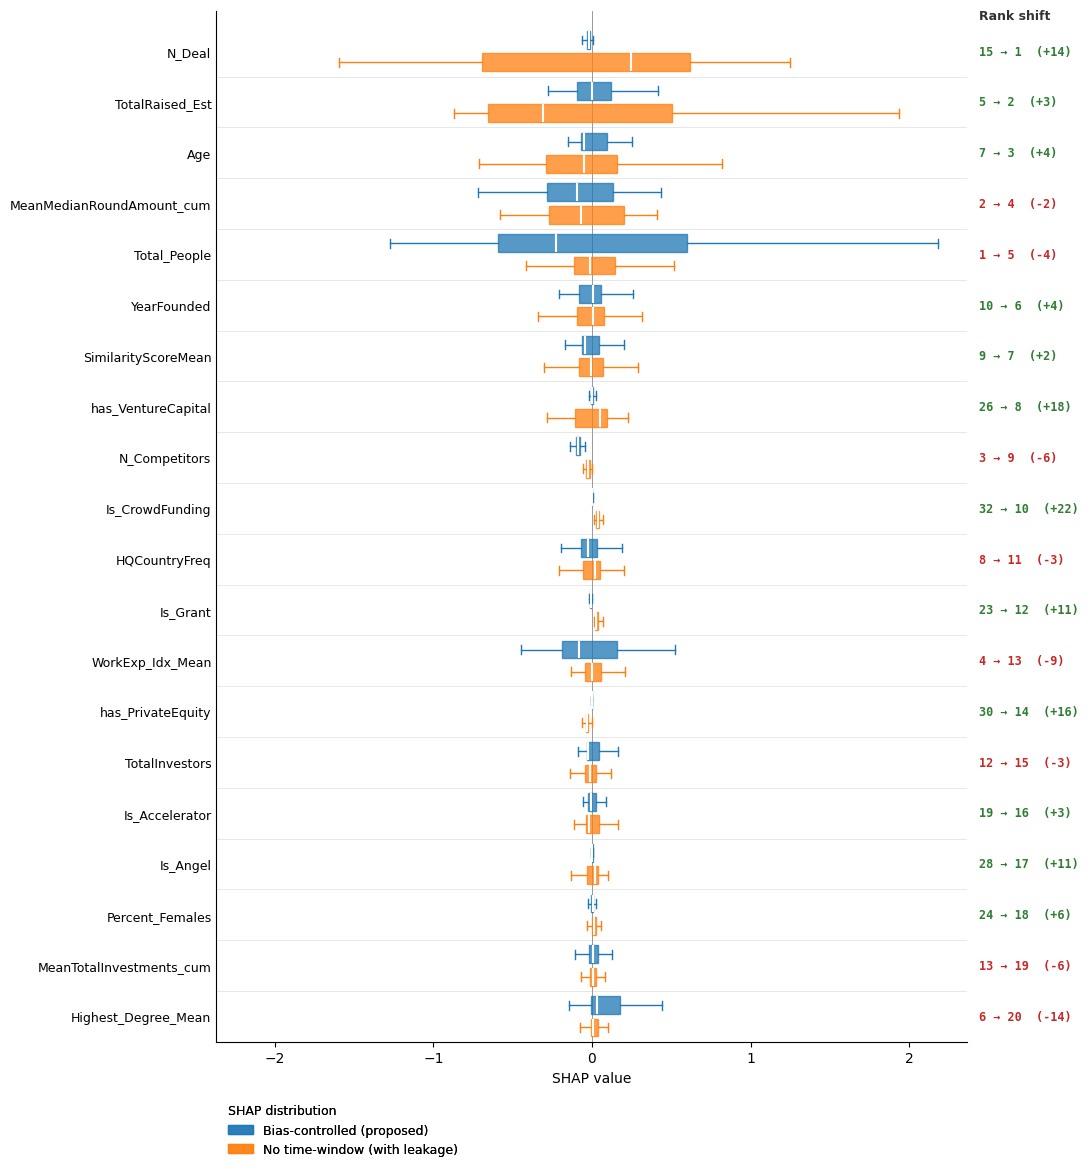

In [ ]:
# =====================================================================
# SHAP distribution comparison: bias-controlled vs no-window (LightGBM)
# Paired horizontal boxplots, ordered by NO-WINDOW top-20 ranking.
# =====================================================================


TOP_K = 20
LEAKAGE_THRESHOLD = 3
OUTPUT_PREFIX = "shap_boxplot_lgbm_nowindow_ordered"

COLOR_BASELINE = "#1f77b4"    # blu
COLOR_NOWINDOW = "#ff7f0e"    # arancio
COLOR_UP       = "#2e7d32"    # verde scuro
COLOR_DOWN     = "#c62828"    # rosso scuro
COLOR_FLAT     = "#616161"    # grigio

# --- 1. Prep ----------------------------------------------------------
def squeeze_shap(sv):
    sv = np.asarray(sv)
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    return sv

sv_b = squeeze_shap(shap_values)
sv_n = squeeze_shap(shap_values_nowindow)

features_baseline = (list(explainer_sample.columns)
                     if hasattr(explainer_sample, "columns")
                     else [f"f{i}" for i in range(sv_b.shape[1])])
features_nowindow = (list(explainer_sample_nowindow.columns)
                     if hasattr(explainer_sample_nowindow, "columns")
                     else [f"f{i}" for i in range(sv_n.shape[1])])

# --- 2. Rankings ------------------------------------------------------
mean_abs_b = np.abs(sv_b).mean(axis=0)
mean_abs_n = np.abs(sv_n).mean(axis=0)

order_n    = np.argsort(-mean_abs_n)
ranking_n  = [features_nowindow[i] for i in order_n][:TOP_K]   # pivot

order_b    = np.argsort(-mean_abs_b)
ranking_b_full = [features_baseline[i] for i in order_b]
rank_base = {f: i + 1 for i, f in enumerate(ranking_b_full)}

idx_base = {f: i for i, f in enumerate(features_baseline)}
idx_now  = {f: i for i, f in enumerate(features_nowindow)}

# --- 3. Figure --------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 0.25 * TOP_K + 2))

Y_OFFSET = 0.22
BOX_WIDTH = 0.35

for i, feat in enumerate(ranking_n):
    # Bias-controlled distribution (blu, sopra)
    if feat in idx_base:
        col_b = idx_base[feat]
        ax.boxplot(
            sv_b[:, col_b],
            positions=[i - Y_OFFSET],
            widths=BOX_WIDTH,
            vert=False,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="white", lw=1.5),
            whiskerprops=dict(color=COLOR_BASELINE, lw=1),
            capprops=dict(color=COLOR_BASELINE, lw=1),
            boxprops=dict(facecolor=COLOR_BASELINE,
                          edgecolor=COLOR_BASELINE, alpha=0.75),
        )
    else:
        ax.axhspan(i - 0.45, i + 0.45, color="#f5f5f5", zorder=0)
        ax.text(0, i - Y_OFFSET,
                "not in bias-controlled model",
                ha="center", va="center", fontsize=8,
                color="#888888", style="italic")

    # No-window distribution (arancio, sotto)
    col_n = idx_now[feat]
    ax.boxplot(
        sv_n[:, col_n],
        positions=[i + Y_OFFSET],
        widths=BOX_WIDTH,
        vert=False,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="white", lw=1.5),
        whiskerprops=dict(color=COLOR_NOWINDOW, lw=1),
        capprops=dict(color=COLOR_NOWINDOW, lw=1),
        boxprops=dict(facecolor=COLOR_NOWINDOW,
                      edgecolor=COLOR_NOWINDOW, alpha=0.75),
    )

# Zero reference line
ax.axvline(0, color="#999999", lw=0.7, zorder=1)

# Y-axis
ax.set_yticks(range(len(ranking_n)))
ax.set_yticklabels(ranking_n, fontsize=9)
ax.invert_yaxis()
ax.set_ylim(len(ranking_n) - 0.5, -0.8)

# X-axis: forza simmetria attorno a zero
xmax = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
ax.set_xlim(-xmax, xmax)
ax.set_xlabel("SHAP value", fontsize=10)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", length=0)

# Light horizontal separators between feature pairs
for i in range(len(ranking_n) - 1):
    ax.axhline(i + 0.5, color="#dddddd", lw=0.5, zorder=0)

# --- 4. Rank-shift annotations on the right --------------------------
xr = 1.015

for i, feat in enumerate(ranking_n):
    new_rank = i + 1
    if feat in rank_base:
        old_rank = rank_base[feat]
        delta = old_rank - new_rank     # >0 = climbed in no-window
        if delta > 0:
            txt = f"{old_rank} → {new_rank}  (+{delta})"
            color = COLOR_UP
        elif delta < 0:
            txt = f"{old_rank} → {new_rank}  ({delta})"
            color = COLOR_DOWN
        else:
            txt = f"{old_rank} → {new_rank}"
            color = COLOR_FLAT
    else:
        txt = f"new → {new_rank}"
        color = COLOR_UP

    ax.text(xr, i, txt,
            ha="left", va="center",
            fontsize=8.5, fontweight="bold", color=color,
            transform=ax.get_yaxis_transform(), clip_on=False,
            family="monospace")

# Header above the rank column
ax.text(xr, -0.7, "Rank shift",
        ha="left", va="center", fontsize=9, fontweight="bold",
        color="#333333", transform=ax.get_yaxis_transform(),
        clip_on=False)

# --- 5. Legends -------------------------------------------------------
# Boxplot color legend (in basso a sinistra)
# Boxplot color legend (in basso a sinistra, dentro l'area della figura ma sotto l'asse x)
box_legend = [
    Patch(facecolor=COLOR_BASELINE, alpha=0.75, edgecolor=COLOR_BASELINE,
          label="Bias-controlled (proposed)"),
    Patch(facecolor=COLOR_NOWINDOW, alpha=0.75, edgecolor=COLOR_NOWINDOW,
          label="No time-window (with leakage)"),
]
leg1 = ax.legend(handles=box_legend,
                 loc="upper left",
                 bbox_to_anchor=(0.0, -0.05),
                 frameon=False, fontsize=9,
                 title="SHAP distribution",
                 title_fontsize=9)
leg1._legend_box.align = "left"
ax.add_artist(leg1)

# Rank-shift color legend (in basso a destra)
# rank_legend = [
#     Line2D([0], [0], marker="s", color="w", markerfacecolor=COLOR_UP,
#            markersize=10, label="Climbed in no-window"),
#     Line2D([0], [0], marker="s", color="w", markerfacecolor=COLOR_DOWN,
#            markersize=10, label="Fell in no-window"),
# ]
# leg2 = ax.legend(handles=rank_legend, loc="lower right",
#                  frameon=False, fontsize=9, title="Rank shift",
#                  title_fontsize=9)
# leg2._legend_box.align = "left"

# --- 6. Save ----------------------------------------------------------
plt.tight_layout()
plt.subplots_adjust(bottom=-0.5)
# fig.savefig(f"{OUTPUT_PREFIX}.pdf", bbox_inches="tight", dpi=300)
fig.savefig(f"img/{OUTPUT_PREFIX}.png", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:

results = []

for feat in ranking_n:
    if feat not in idx_base:
        continue

    col_b = idx_base[feat]
    col_n = idx_now[feat]

    x_b = sv_b[:, col_b]
    x_n = sv_n[:, col_n]

    n_pairs = min(len(x_b), len(x_n))
    x_b = x_b[:n_pairs]
    x_n = x_n[:n_pairs]

    abs_b = np.abs(x_b)
    abs_n = np.abs(x_n)

    try:
        w_stat, w_p = wilcoxon(abs_b, abs_n, alternative="two-sided")
    except ValueError:
        w_stat, w_p = np.nan, 1.0

    results.append({
        "feature":            feat,
        "mean_imp_baseline":  abs_b.mean(),
        "mean_imp_nowindow":  abs_n.mean(),
        "diff_imp":           abs_b.mean() - abs_n.mean(),
        "wilcoxon_stat":      w_stat,
        "wilcoxon_p_value":   w_p,
    })
    

df = pd.DataFrame(results)

# FDR correction (Benjamini-Hochberg)
mask = df["wilcoxon_p_value"].notna()
_, p_corrected, _, _ = multipletests(
    df.loc[mask, "wilcoxon_p_value"].values,
    method="fdr_bh",
    alpha=0.05,
)
df.loc[mask, "wilcoxon_p_corrected"] = p_corrected

print(df.to_string(index=False))

                  feature  mean_imp_baseline  mean_imp_nowindow  diff_imp  wilcoxon_stat  wilcoxon_p_value  wilcoxon_p_corrected
                   N_Deal           0.039386           0.655990 -0.616604          582.0     1.905155e-164         1.905155e-163
          TotalRaised_Est           0.119701           0.651304 -0.531603         5702.0     7.457986e-158         3.728993e-157
                      Age           0.085805           0.250188 -0.164383        40736.0     2.132890e-116         4.739756e-116
MeanMedianRoundAmount_cum           0.219108           0.223547 -0.004439       231779.0      4.318872e-02          4.318872e-02
             Total_People           0.682584           0.149880  0.532703        10438.0     7.072602e-152         2.357534e-151
              YearFounded           0.071583           0.135561 -0.063978       162985.0      1.269244e-21          1.658546e-21
      SimilarityScoreMean           0.072256           0.122492 -0.050237       163027.0      1.3